### Comparing FCs across different cohorts

In [4]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = "/Users/achechenina/projects/centenerians"

In [5]:
# reading ciao escape genes
ciao_ukbb_classified = pd.read_csv("/Users/achechenina/projects/centenerians/results/data/escape_analysis/ukbb_centenarian_overlap_classified.csv")
# saving genes to txt file 
with open("/Users/achechenina/projects/centenerians/results/data/escape_analysis/ciao_ukbb_escape_genes.txt", "w") as f:
    for gene in ciao_ukbb_classified[ciao_ukbb_classified['Category'] == 'Escape']['Gene'].to_list():
        f.write(f"{gene}\n")

In [14]:
necs_full.head()

,SomaID,uniprot,geneID,FC.cont2cent,FC.off2cent,F.test,Pval.Ftest,Adj.Pvalue,Gene,log2FC.cent2cont,log2FC.cent2off
0,14042-11_3,Q8N474,SFRP1,0.299923,0.271781,115.233152,7.910000e-35,3.784940e-31,SFRP1,1.737338,1.879484
1,3045-72_2,P21246,PTN,0.424080,0.412717,112.182511,3.880000e-34,9.282900e-31,PTN,1.237592,1.276775
2,9756-6_3,Q01995,TAGLN,0.455853,0.407945,94.386544,2.740000e-30,4.370300e-27,TAGLN,1.133361,1.293553
3,3362-61_2,Q9BU40,CHRDL1,0.533674,0.500435,91.469918,1.430000e-29,1.710640e-26,CHRDL1,0.905969,0.998744
4,8304-50_3,O00300,TNFRSF11B,0.527240,0.525521,80.418739,6.500000e-27,6.220500e-24,TNFRSF11B,0.923469,0.928180


In [ ]:
# make a heatmap for all those genes representing log2FC for each comparison:
# beta for ukbb, log2FC for ciao, FC.cont2cent for necs

# reading data
ukbb_full = pd.read_csv(Path(PROJECT_ROOT) / "results" / "data" / "ukbb_gene_name_preprocessed_full.csv") # Age_Beta
necs_full = pd.read_csv(Path(PROJECT_ROOT) / "data/New_England_Sebastiani/cent2cont_table.csv") # log2FC.cent2cont, log2FC.cent2off
swiss_cent_healthy = pd.read_excel(Path(PROJECT_ROOT) / "data/SWISS100/acel70409-sup-0005-tables2.xlsx", sheet_name="2.a Centenarian - Healthy", index_col=0)
swiss_cent_geriatric = pd.read_excel(Path(PROJECT_ROOT) / "data/SWISS100/acel70409-sup-0005-tables2.xlsx", sheet_name="2.b Centenarian - Geriatric", index_col=0)
swiss_geriatric_healthy = pd.read_excel(Path(PROJECT_ROOT) / "data/SWISS100/acel70409-sup-0005-tables2.xlsx", sheet_name="2.c Geriatric - Healthy", index_col=0)

meta_dict = {'ciao': {'data': ciao_ukbb_classified, 'genecol': 'PG.Genes', 'log2fc_col': 'log2FC', 'padj_col': 'padj'}, # centenarian vs control
            'ukbb': {'data': ukbb_full, 'genecol': 'Gene', 'log2fc_col': 'Age_Beta', 'padj_col': 'Age_pvalue'}, # betas for age variable
            'necs_cent_cont': {'data': necs_full, 'genecol': 'Gene', 'log2fc_col': 'log2FC.cent2cont', 'padj_col': 'Adj.Pvalue'}, # centenarian vs control
            'necs_cent_off': {'data': necs_full, 'genecol': 'Gene', 'log2fc_col': 'log2FC.cent2off', 'padj_col': 'Adj.Pvalue'}, # centenarian vs offspring
            'swiss_cent_geriatric': {'data': swiss_cent_geriatric, 'genecol': 'Assay', 'log2fc_col': 'log2FoldChange', 'padj_col': 'Adjusted_pval'},
            'swiss_cent_healthy': {'data': swiss_cent_healthy, 'genecol': 'Assay', 'log2fc_col': 'log2FoldChange', 'padj_col': 'Adjusted_pval'},
            'swiss_geriatric_healthy': {'data': swiss_geriatric_healthy, 'genecol': 'Assay', 'log2fc_col': 'log2FoldChange', 'padj_col': 'Adjusted_pval'}} # centenarian vs healthy, not geriatric

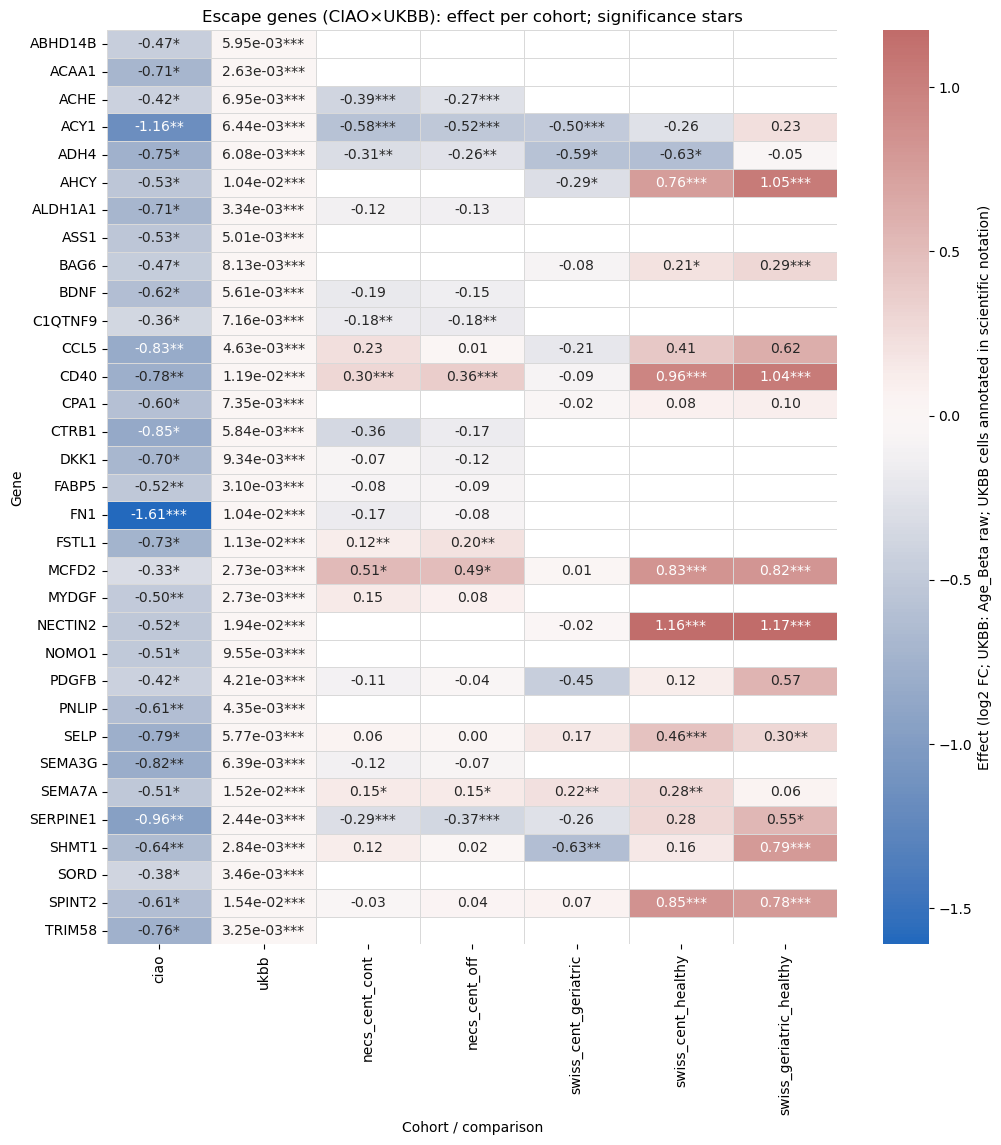

Saved: /Users/achechenina/projects/centenerians/results/plots/escape_analysis/escape_genes_effects_heatmap.png


In [20]:
# Heatmap: CIAO×UKBB **Escape** genes × cohorts (CIAO/NECS/SWISS: log2 fold-change; UKBB: Age_Beta).
# Stars from each cohort's p/FDR column: *** p<0.001, ** p<0.01, * p<0.05.
# UKBB `Age_Beta` is small; **cell text** uses scientific notation (e.g. 2.4e-03) instead of rescaling.

def _first_gene_symbol(x: object) -> str:
    if pd.isna(x):
        return ""
    return str(x).split(";")[0].strip().upper()


def _stars(p: float) -> str:
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def _annot_effect(cohort: str, v: float) -> str:
    if cohort == "ukbb":
        return f"{v:.2e}"
    return f"{v:.2f}"


_escape = ciao_ukbb_classified[ciao_ukbb_classified["Category"] == "Escape"].copy()
if "gene_symbol_match" in _escape.columns:
    _escape["_g"] = _escape["gene_symbol_match"].map(_first_gene_symbol)
else:
    _escape["_g"] = _escape["Gene"].map(_first_gene_symbol)
escape_genes = sorted(g for g in _escape["_g"].unique() if g)

cohort_order = list(meta_dict.keys())
lfc_mat = pd.DataFrame(np.nan, index=escape_genes, columns=cohort_order, dtype=float)
p_mat = pd.DataFrame(np.nan, index=escape_genes, columns=cohort_order, dtype=float)

for cohort, meta in meta_dict.items():
    df = meta["data"].copy()
    gc = meta["genecol"]
    if gc not in df.columns and gc == "Gene" and "gene_symbol_match" in df.columns:
        df["_g"] = df["gene_symbol_match"].map(_first_gene_symbol)
    else:
        df["_g"] = df[gc].map(_first_gene_symbol)
    pv = pd.to_numeric(df[meta["padj_col"]], errors="coerce")
    df = df.assign(_pv=pv).sort_values("_pv", na_position="last").drop_duplicates("_g", keep="first")
    lfc = pd.to_numeric(df[meta["log2fc_col"]], errors="coerce")
    sub = pd.DataFrame({"_g": df["_g"], "lfc": lfc, "pv": df["_pv"]}).dropna(subset=["_g"])
    sub = sub[sub["_g"].isin(escape_genes)].drop_duplicates("_g", keep="first").set_index("_g")
    for g in escape_genes:
        if g in sub.index:
            lfc_mat.loc[g, cohort] = sub.loc[g, "lfc"]
            p_mat.loc[g, cohort] = sub.loc[g, "pv"]

annot = pd.DataFrame("", index=escape_genes, columns=cohort_order, dtype=object)
for g in escape_genes:
    for c in cohort_order:
        v, p = lfc_mat.loc[g, c], p_mat.loc[g, c]
        if pd.notna(v):
            annot.loc[g, c] = f"{_annot_effect(c, v)}{_stars(p)}"
        else:
            annot.loc[g, c] = "—"

_h = max(6.0, 0.35 * len(escape_genes))
fig, ax = plt.subplots(figsize=(1.2 * len(cohort_order) + 2, _h))
sns.heatmap(
    lfc_mat.astype(float),
    annot=annot,
    fmt="",
    cmap="vlag",
    center=0.0,
    linewidths=0.5,
    linecolor="0.85",
    cbar_kws={"label": "Effect (log2 FC; UKBB: Age_Beta raw; UKBB cells annotated in scientific notation)"},
    ax=ax,
)
ax.set_title("Escape genes (CIAO×UKBB): effect per cohort; significance stars")
ax.set_xlabel("Cohort / comparison")
ax.set_ylabel("Gene")
plt.tight_layout()
_out = Path(PROJECT_ROOT) / "results" / "plots" / "escape_analysis" / "escape_genes_effects_heatmap.png"
_out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {_out}")


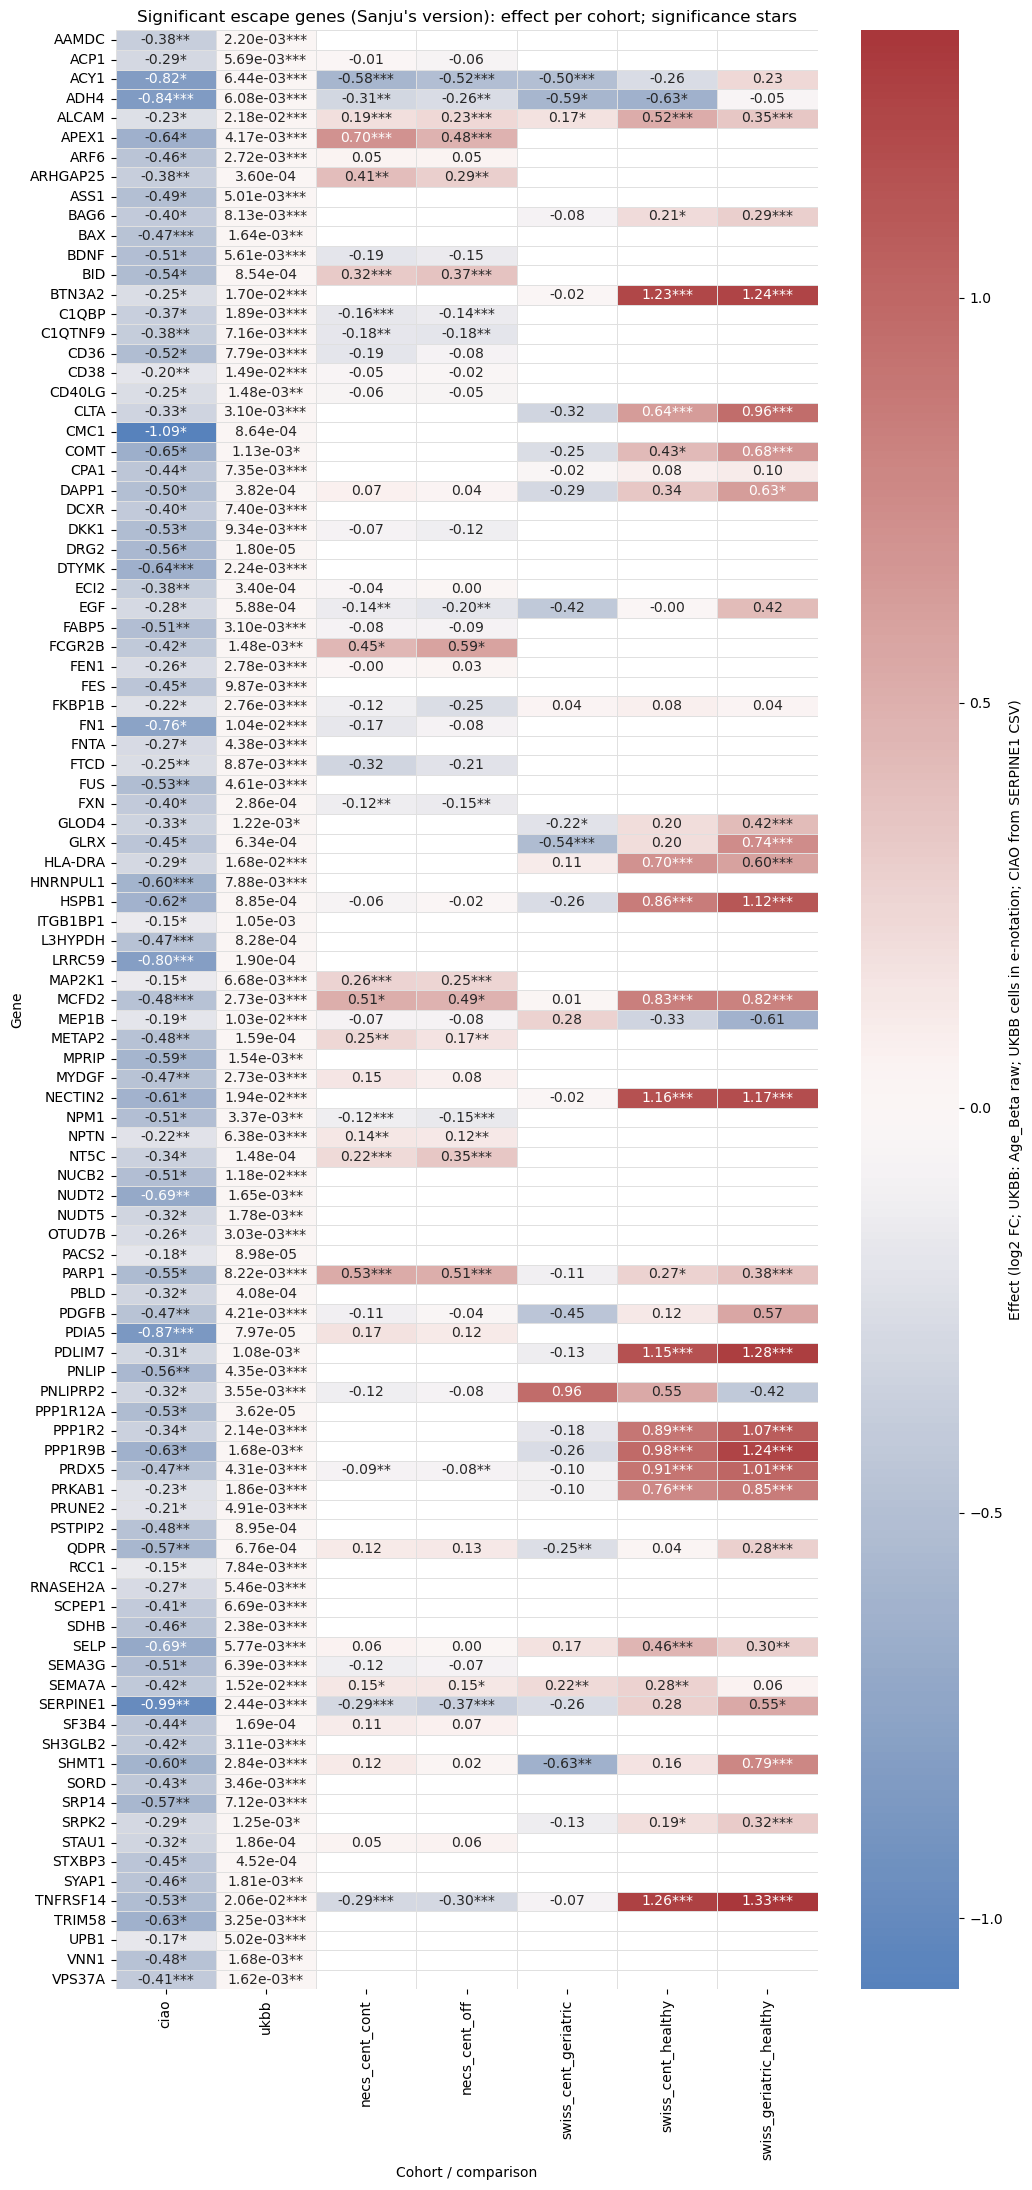

Saved: /Users/achechenina/projects/centenerians/results/plots/escape_analysis/escape_genes_effects_heatmap_sanjus_list.png  (n_genes=100)


In [21]:
# SERPINE1 `significant_escape_genes.csv`: same layout as the CIAO×UKBB escape heatmap.
# — CIAO column: **Log2FC** (stars from **FDR**) from this CSV, not from `ciao_ukbb_classified`.
# — UKBB: raw **Age_Beta**; **cell text** uses scientific notation (same as the previous heatmap).
# — Other cohorts: `meta_dict` lookup; stars from each cohort's padj/p column.


def _first_gene_symbol(x: object) -> str:
    if pd.isna(x):
        return ""
    return str(x).split(";")[0].strip().upper()


def _stars(p: float) -> str:
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def _annot_effect(cohort: str, v: float) -> str:
    if cohort == "ukbb":
        return f"{v:.2e}"
    return f"{v:.2f}"


_SERPIN_CSV = (
    Path(PROJECT_ROOT)
    / "sanju_version/2_results/SERPINE1_escape_analysis/task4_gene_excel/significant_escape_genes.csv"
)
_sig_escape_tbl = pd.read_csv(_SERPIN_CSV)
escape_genes = sorted(
    {
        _first_gene_symbol(x)
        for x in _sig_escape_tbl["Gene"].astype(str)
        if _first_gene_symbol(x)
    }
)

cohort_order = list(meta_dict.keys())
lfc_mat_se = pd.DataFrame(np.nan, index=escape_genes, columns=cohort_order, dtype=float)
p_mat_se = pd.DataFrame(np.nan, index=escape_genes, columns=cohort_order, dtype=float)

for cohort, meta in meta_dict.items():
    if cohort == "ciao":
        continue
    df = meta["data"].copy()
    gc = meta["genecol"]
    if gc not in df.columns and gc == "Gene" and "gene_symbol_match" in df.columns:
        df["_g"] = df["gene_symbol_match"].map(_first_gene_symbol)
    else:
        df["_g"] = df[gc].map(_first_gene_symbol)
    pv = pd.to_numeric(df[meta["padj_col"]], errors="coerce")
    df = df.assign(_pv=pv).sort_values("_pv", na_position="last").drop_duplicates("_g", keep="first")
    lfc = pd.to_numeric(df[meta["log2fc_col"]], errors="coerce")
    sub = pd.DataFrame({"_g": df["_g"], "lfc": lfc, "pv": df["_pv"]}).dropna(subset=["_g"])
    sub = sub[sub["_g"].isin(escape_genes)].drop_duplicates("_g", keep="first").set_index("_g")
    for g in escape_genes:
        if g in sub.index:
            lfc_mat_se.loc[g, cohort] = sub.loc[g, "lfc"]
            p_mat_se.loc[g, cohort] = sub.loc[g, "pv"]

_ciao_tbl = _sig_escape_tbl.copy()
_ciao_tbl["_g"] = _ciao_tbl["Gene"].map(_first_gene_symbol)
_ciao_tbl = _ciao_tbl.drop_duplicates("_g", keep="first").set_index("_g")
for g in escape_genes:
    if g in _ciao_tbl.index:
        lfc_mat_se.loc[g, "ciao"] = pd.to_numeric(_ciao_tbl.loc[g, "Log2FC"], errors="coerce")
        p_mat_se.loc[g, "ciao"] = pd.to_numeric(_ciao_tbl.loc[g, "FDR"], errors="coerce")

annot_se = pd.DataFrame("", index=escape_genes, columns=cohort_order, dtype=object)
for g in escape_genes:
    for c in cohort_order:
        v, p = lfc_mat_se.loc[g, c], p_mat_se.loc[g, c]
        if pd.notna(v):
            annot_se.loc[g, c] = f"{_annot_effect(c, v)}{_stars(p)}"
        else:
            annot_se.loc[g, c] = "—"

_h = max(8.0, 0.22 * len(escape_genes))
fig, ax = plt.subplots(figsize=(1.2 * len(cohort_order) + 2, _h))
sns.heatmap(
    lfc_mat_se.astype(float),
    annot=annot_se,
    fmt="",
    cmap="vlag",
    center=0.0,
    linewidths=0.4,
    linecolor="0.88",
    cbar_kws={
        "label": "Effect (log2 FC; UKBB: Age_Beta raw; UKBB cells in e-notation; CIAO from SERPINE1 CSV)",
    },
    ax=ax,
)
ax.set_title("Significant escape genes (Sanju's version): effect per cohort; significance stars")
ax.set_xlabel("Cohort / comparison")
ax.set_ylabel("Gene")
plt.tight_layout()
_out_se = (
    Path(PROJECT_ROOT)
    / "results"
    / "plots"
    / "escape_analysis"
    / "escape_genes_effects_heatmap_sanjus_list.png"
)
_out_se.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_out_se, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {_out_se}  (n_genes={len(escape_genes)})")
